# Predicción del reemplazo de baterias de litio - SVM 

---

**Autor:** Borja Mora Mendez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoria:** Machine Learning · Supervisado · Regresion · Support Vector Machines

---

### Objetivo

Predecir la **capacidad restante (%)** de una bateria a partir de su edad e intensidad de uso, usando SVR con diferentes kernels. La degradacion de baterias sigue un patron no lineal (exponencial/sigmoide) — un caso ideal para SVR.

**El cliente:** un fabricante de dispositivos electronicos que necesita predecir cuando sus baterias necesitaran reemplazo.

**El problema:** reemplazar una bateria demasiado pronto es un coste innecesario; demasiado tarde causa fallos en campo. Un modelo que prediga la capacidad restante permite programar reemplazos preventivos.

**La pregunta:** se puede predecir la capacidad de una bateria (%) a partir de su edad y patron de uso?


- **Edad_Anos**: cuántos años tiene la batería
- **Intensidad_Uso**: qué tan intensamente se ha usado (0 a 100)
- **Requiere_Reemplazo**: la variable objetivo → 0 (sana) o 1 (necesita reemplazo)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

plt.style.use("seaborn-v0_8-whitegrid")

# Estilo visual — sistema de color validado (consejo UX/UI Data)
BACKGROUND   = '#fbfbfb'
PURPLE       = '#7a7bff'   # único color de énfasis (1 por gráfico)
PURPLE_LIGHT = '#9b9cff'   # EDA de una sola serie (histogramas) -- PURPLE fuerte queda solo para el enfasis
POSITIVE     = '#6b8158'   # exclusivo signo positivo
NEGATIVE     = '#c34031'   # exclusivo signo negativo
NEUTRAL_BAR  = '#d9d9d9'   # barras/áreas de contexto (siempre con etiqueta de valor)
NEUTRAL_LINE = '#8f8c9e'   # líneas de contexto (más contraste que NEUTRAL_BAR)
CONTEXT_LINES = [NEUTRAL_LINE, '#a89a8a', '#7d94a8']   # gama fija para 2+ lineas de contexto en un mismo grafico
INK          = '#111111'
MUTED        = '#707070'

# Alias de compatibilidad con el resto del notebook
GREEN, RED, GRAY = POSITIVE, NEGATIVE, NEUTRAL_BAR

DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "borja_diverging", ["#c34031", "#e0a89f", "#f0ede8", "#b7c2a9", "#6b8158"]
)
SEQUENTIAL_GREEN = LinearSegmentedColormap.from_list(
    "borja_sequential", [BACKGROUND, POSITIVE]
)

def color_annotations(ax, values, threshold, dark="#ffffff", light=INK):
    """Recolorea el texto de un heatmap celda a celda según su magnitud."""
    for text, value in zip(ax.texts, np.asarray(values).flatten()):
        text.set_color(dark if abs(value) >= threshold else light)

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'figure.facecolor': BACKGROUND,
    'axes.facecolor': BACKGROUND,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

## 1. Carga y validación de datos

In [2]:
data = pd.read_excel("datos_baterias.xlsx")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()


Registros: 119 | Columnas: 3


,Edad_Anos,Intensidad_Uso,Requiere_Reemplazo
0,1.70,69.47,1
1,4.31,61.12,1
2,1.48,15.34,0
3,2.76,42.18,1
4,5.04,95.61,1


## 2. EDA

,Edad_Anos,Intensidad_Uso,Requiere_Reemplazo
count,119.000000,119.000000,119.000000
mean,3.384874,62.099664,0.722689
std,1.494989,23.128248,0.449564
min,0.580000,12.410000,0.000000
25%,2.135000,43.680000,0.000000
50%,3.370000,63.890000,1.000000
75%,4.695000,82.845000,1.000000
max,5.920000,98.620000,1.000000


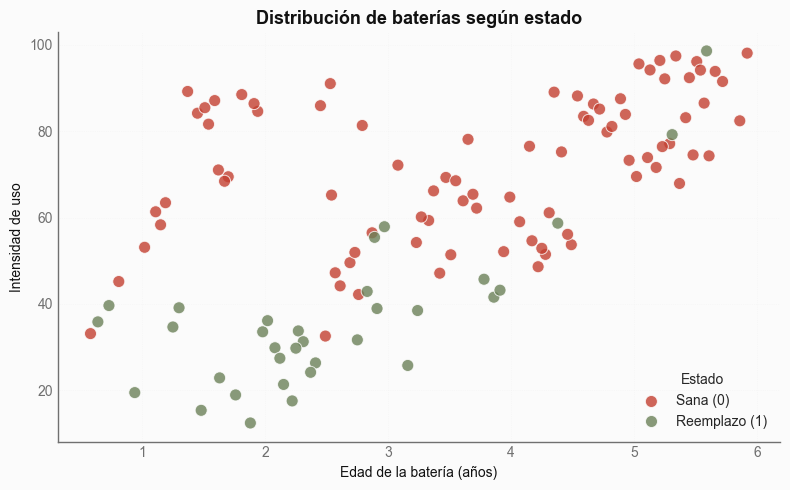

In [3]:
display(data.describe())

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=data, x="Edad_Anos", y="Intensidad_Uso", hue="Requiere_Reemplazo", palette={0:POSITIVE,1:NEGATIVE}, s=75, edgecolor="white", alpha=.8, ax=ax)
ax.set_title("Distribución de baterías según estado")
ax.set_xlabel("Edad de la batería (años)")
ax.set_ylabel("Intensidad de uso")
ax.legend(title="Estado", labels=["Sana (0)", "Reemplazo (1)"])
ax.grid(True, linestyle=":", alpha=.6)
plt.tight_layout(); plt.show()


## 3. Preparación: Train / Test y estandarización

In [4]:
X = data[["Edad_Anos", "Intensidad_Uso"]]
y = data["Requiere_Reemplazo"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

escalador = StandardScaler()
X_train_scaled = escalador.fit_transform(X_train)
X_test_scaled = escalador.transform(X_test)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")


Train: 83 | Test: 36


## 4. SVM - Kernel lineal

In [5]:
modelo_lineal = SVC(kernel="linear", C=2.0, random_state=42)
modelo_lineal.fit(X_train_scaled, y_train)
y_pred_lineal = modelo_lineal.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lineal, target_names=["Está Sana (0)", "Necesita Reemplazo (1)"], digits=3))


                        precision    recall  f1-score   support

         Está Sana (0)      0.800     0.800     0.800        10
Necesita Reemplazo (1)      0.923     0.923     0.923        26

              accuracy                          0.889        36
             macro avg      0.862     0.862     0.862        36
          weighted avg      0.889     0.889     0.889        36



## 5. SVM - Kernel polinómico grado 2

In [6]:
modelo_poly2 = SVC(kernel="poly", degree=2, C=1.0, gamma="scale", coef0=1, random_state=42)
modelo_poly2.fit(X_train_scaled, y_train)
y_pred_poly2 = modelo_poly2.predict(X_test_scaled)

print(classification_report(y_test, y_pred_poly2, target_names=["Está Sana (0)", "Necesita Reemplazo (1)"], digits=3))


                        precision    recall  f1-score   support

         Está Sana (0)      0.889     0.800     0.842        10
Necesita Reemplazo (1)      0.926     0.962     0.943        26

              accuracy                          0.917        36
             macro avg      0.907     0.881     0.893        36
          weighted avg      0.916     0.917     0.915        36



## 6. SVM - Kernel polinómico grado 3

In [7]:
modelo_poly3 = SVC(kernel="poly", degree=3, C=1.0, gamma="scale", coef0=1, random_state=42)
modelo_poly3.fit(X_train_scaled, y_train)
y_pred_poly3 = modelo_poly3.predict(X_test_scaled)

print(classification_report(y_test, y_pred_poly3, target_names=["Está Sana (0)", "Necesita Reemplazo (1)"], digits=3))


                        precision    recall  f1-score   support

         Está Sana (0)      0.889     0.800     0.842        10
Necesita Reemplazo (1)      0.926     0.962     0.943        26

              accuracy                          0.917        36
             macro avg      0.907     0.881     0.893        36
          weighted avg      0.916     0.917     0.915        36



## 7. Comparación visual de las fronteras

c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


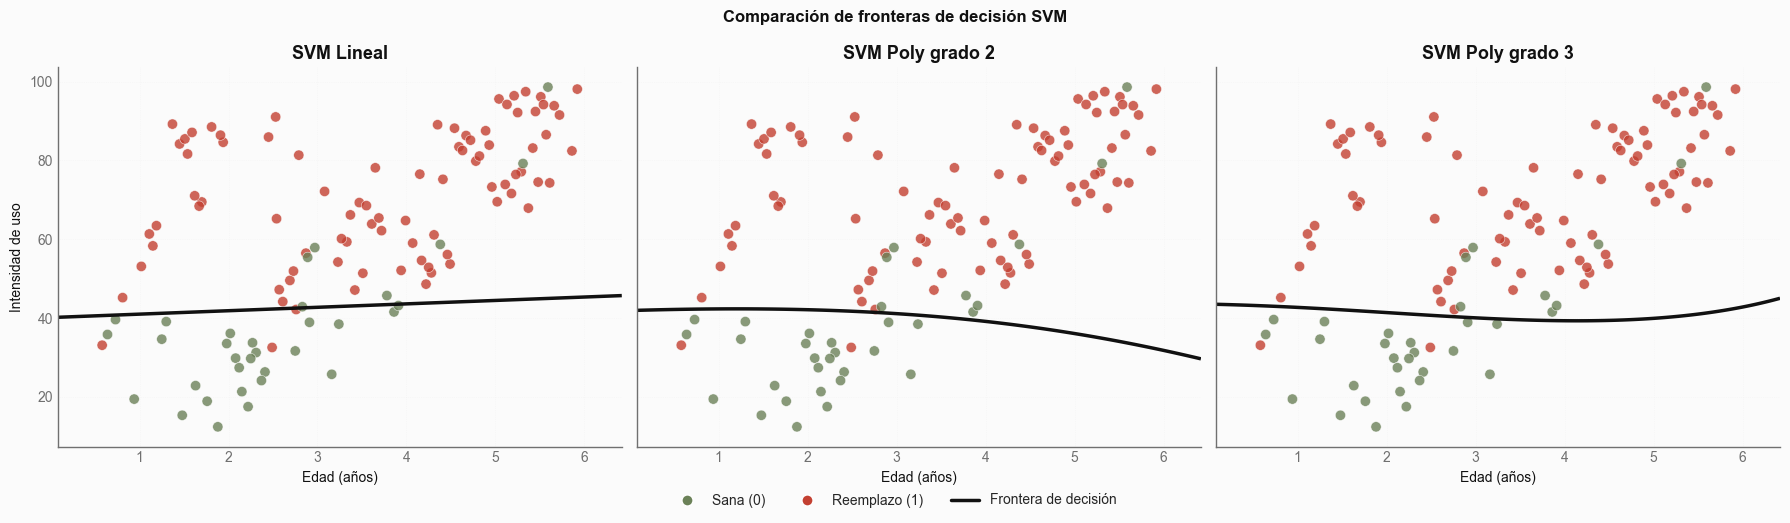

In [8]:
x_min, x_max = data["Edad_Anos"].min()-0.5, data["Edad_Anos"].max()+0.5
y_min, y_max = data["Intensidad_Uso"].min()-5, data["Intensidad_Uso"].max()+5
xx, yy = np.meshgrid(np.linspace(x_min,x_max,500), np.linspace(y_min,y_max,500))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = escalador.transform(grid)

modelos = [("SVM Lineal", modelo_lineal), ("SVM Poly grado 2", modelo_poly2), ("SVM Poly grado 3", modelo_poly3)]
fig, axes = plt.subplots(1,3,figsize=(18,5),sharey=True)

for ax,(titulo,modelo) in zip(axes,modelos):
    decision = modelo.decision_function(grid_scaled).reshape(xx.shape)
    sns.scatterplot(data=data,x="Edad_Anos",y="Intensidad_Uso",hue="Requiere_Reemplazo",palette={0:POSITIVE,1:NEGATIVE},s=55,edgecolor="white",linewidth=.4,alpha=.8,legend=False,ax=ax)
    ax.contour(xx,yy,decision,levels=[0],colors=INK,linewidths=2.5)
    ax.set_title(titulo)
    ax.set_xlabel("Edad (años)")
    ax.grid(True,linestyle=":",alpha=.6)
axes[0].set_ylabel("Intensidad de uso")
handles=[Line2D([0],[0],marker='o',color='none',markerfacecolor=POSITIVE,markeredgecolor='white',markersize=8,label='Sana (0)'),Line2D([0],[0],marker='o',color='none',markerfacecolor=NEGATIVE,markeredgecolor='white',markersize=8,label='Reemplazo (1)'),Line2D([0],[0],color=INK,lw=2.5,label='Frontera de decisión')]
fig.legend(handles=handles,loc='lower center',ncol=3,frameon=False,bbox_to_anchor=(.5,-.04))
fig.suptitle("Comparación de fronteras de decisión SVM",fontweight='bold',color=INK)
plt.tight_layout(); plt.show()


## 8. Comparación final

In [9]:
modelos = {
    "SVM Lineal": (modelo_lineal, y_pred_lineal),
    "SVM Poly grado 2": (modelo_poly2, y_pred_poly2),
    "SVM Poly grado 3": (modelo_poly3, y_pred_poly3),
}

filas=[]
for nombre,(modelo,pred) in modelos.items():
    r=classification_report(y_test,pred,output_dict=True)
    filas.append({
        "Modelo":nombre,
        "Precision Reemplazo":round(r["1"]["precision"],3),
        "Recall Reemplazo":round(r["1"]["recall"],3),
        "F1 Reemplazo":round(r["1"]["f1-score"],3),
        "Accuracy":round(r["accuracy"],3),
        "F1 Macro":round(r["macro avg"]["f1-score"],3),
        "Vectores Soporte":len(modelo.support_vectors_)
    })

df_comparativa=pd.DataFrame(filas).sort_values("Recall Reemplazo",ascending=False)
display(df_comparativa)


,Modelo,Precision Reemplazo,Recall Reemplazo,F1 Reemplazo,Accuracy,F1 Macro,Vectores Soporte
1,SVM Poly grado 2,0.926,0.962,0.943,0.917,0.893,26
2,SVM Poly grado 3,0.926,0.962,0.943,0.917,0.893,24
0,SVM Lineal,0.923,0.923,0.923,0.889,0.862,28


## 9. Conclusión final

El ejercicio confirma que **SVM es capaz de separar las baterías según su necesidad de reemplazo utilizando únicamente dos variables: edad e intensidad de uso**.

Con el dataset corregido de **119 registros**, el test contiene 36 observaciones. Al volver a ejecutar el notebook, los resultados obtenidos son:

- **SVM Lineal:** accuracy **88,9%** y recall de reemplazo **92,3%**.
- **SVM Poly grado 2:** accuracy **91,7%** y recall de reemplazo **96,2%**.
- **SVM Poly grado 3:** accuracy **91,7%** y recall de reemplazo **96,2%**.

### Lectura de negocio

El criterio más importante no debería ser únicamente la accuracy. En este caso, es especialmente relevante el **recall de la clase 1**, porque representa la capacidad del modelo para detectar baterías que realmente necesitan reemplazo.

Por tanto, **Poly grado 2 y Poly grado 3 son las mejores alternativas de las tres probadas**: detectan aproximadamente el **96% de las baterías que requieren reemplazo** y alcanzan un **91,7% de accuracy** en el conjunto de test. El grado 3 no aporta una mejora frente al grado 2, por lo que **Poly grado 2 sería la opción preferible por simplicidad**.

Hay, no obstante, una limitación importante: el dataset es pequeño y el conjunto de test contiene solo 36 observaciones. Por ello, estos resultados deben interpretarse como una primera prueba del enfoque y no como evidencia suficiente para desplegar el modelo en producción. El siguiente paso sería validar los kernels mediante **validación cruzada** y ampliar el dataset con más baterías reales.
